In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob

In [2]:
news_df = pd.read_csv("data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("data/NVDA.csv")
news_df.columns = news_df.columns.str.strip().str.lower()
stock_df.columns = stock_df.columns.str.strip().str.lower()
print(news_df.isnull().sum())
print(stock_df.isnull().sum())

news_df["date"] = news_df["date"].astype(str).str.strip()

# 2. convert to datetime
# 1. force string + clean
news_df["date"] = news_df["date"].astype(str).str.strip()

# 2. robust parsing (handles timezone + mixed formats)
news_df["date"] = pd.to_datetime(
    news_df["date"],
    errors="coerce",
    utc=True,
    format="mixed"
)

# 3. create trading date
news_df["trading_date"] = news_df["date"].dt.date





stock_df["date"] = news_df["date"].astype(str).str.strip()

# 2. robust parsing (handles timezone + mixed formats)
stock_df["date"] = pd.to_datetime(
   stock_df["date"],
    errors="coerce",
    utc=True,
    format="mixed"
)

# 3. create trading date
stock_df["trading_date"] = news_df["date"].dt.date

stock_df.head(2)


unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


,date,close,high,low,open,volume,trading_date
0,2020-06-05 14:30:54+00:00,0.199652,0.201027,0.184294,0.184982,497124000,2020-06-05
1,2020-06-03 14:45:20+00:00,0.203319,0.207904,0.195984,0.197360,705736000,2020-06-03


In [3]:
stock_df["trading_date"] = pd.to_datetime(stock_df["date"]).dt.date

trading_days = sorted(stock_df["trading_date"].unique())
import numpy as np

def get_next_trading_day(date):
    for d in trading_days:
        if d >= date:
            return d
    return np.nan
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce", utc=True)

news_df["raw_date"] = news_df["date"].dt.date
news_df["trading_date"] = news_df["raw_date"].apply(get_next_trading_day)
print(news_df[["raw_date", "trading_date"]].head(10))

     raw_date trading_date
0  2020-06-05   2020-06-05
1  2020-06-03   2020-06-03
2  2020-05-26   2020-05-26
3  2020-05-22   2020-05-22
4  2020-05-22   2020-05-22
5  2020-05-22   2020-05-22
6  2020-05-22   2020-05-22
7  2020-05-22   2020-05-22
8  2020-05-22   2020-05-22
9  2020-05-22   2020-05-22


Sentimental Analysis 

In [4]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()
news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)
def label_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

news_df["sentiment_label"] = news_df["sentiment_score"].apply(label_sentiment)
news_df[["headline", "sentiment_score"]].head(10)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\cbe\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296
5,"CFRA Maintains Hold on Agilent Technologies, L...",-0.128
6,"UBS Maintains Neutral on Agilent Technologies,...",0.000
7,Agilent Technologies shares are trading higher...,0.296
8,Wells Fargo Maintains Overweight on Agilent Te...,-0.128
9,10 Biggest Price Target Changes For Friday,0.000


In [5]:
stock_df["daily_pct_change"] = (
    stock_df["close"].pct_change() * 100
    
)
stock_df.head()

,date,close,high,low,open,volume,trading_date,daily_pct_change
0,2020-06-05 14:30:54+00:00,2.721686,2.730385,2.554037,2.575630,746015200,2020-06-05,NaN
1,2020-06-03 14:45:20+00:00,2.836553,2.884539,2.780469,2.794266,1181608400,2020-06-03,4.220416
2,2020-05-26 08:30:07+00:00,2.789767,2.914229,2.770872,2.877641,1289310400,2020-05-26,-1.649399
3,2020-05-22 16:45:06+00:00,2.729484,2.774170,2.706990,2.753477,753048800,2020-05-22,-2.160860
4,2020-05-22 15:38:59+00:00,2.780169,2.793666,2.700393,2.712090,673500800,2020-05-22,1.856959


Aggregate and Correlate

In [6]:
import os

# -----------------------------
# STEP 1: Get available stocks
# -----------------------------
folder_path = "data/"

available_stocks = []

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        stock_name = file.replace(".csv", "")

        available_stocks.append(stock_name)

# -----------------------------
# STEP 2: Keep only matching stocks
# -----------------------------
news_df = news_df[
    news_df["stock"].isin(available_stocks)
]

# -----------------------------
# STEP 3: Calculate sentiment
# -----------------------------
news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

# -----------------------------
# STEP 4: Create trading date
# -----------------------------
news_df["trading_date"] = news_df["date"].dt.date

# -----------------------------
# STEP 5: Aggregate daily sentiment
# -----------------------------
daily_sentiment = news_df.groupby(
    ["stock", "trading_date"]
)["sentiment_score"].mean().reset_index()


print(daily_sentiment.head(50))

   stock trading_date  sentiment_score
0   AAPL   2020-03-09        -0.302067
1   AAPL   2020-03-10        -0.090787
2   AAPL   2020-03-11        -0.023850
3   AAPL   2020-03-12        -0.078360
4   AAPL   2020-03-13        -0.059727
5   AAPL   2020-03-14         0.000000
6   AAPL   2020-03-15         0.000000
7   AAPL   2020-03-16         0.044191
8   AAPL   2020-03-17        -0.006300
9   AAPL   2020-03-18        -0.077400
10  AAPL   2020-03-19         0.191300
11  AAPL   2020-03-20         0.434450
12  AAPL   2020-03-21         0.000000
13  AAPL   2020-03-23        -0.185850
14  AAPL   2020-03-24         0.119200
15  AAPL   2020-03-25         0.166925
16  AAPL   2020-03-26         0.440400
17  AAPL   2020-03-27         0.160867
18  AAPL   2020-03-28         0.000000
19  AAPL   2020-03-29         0.340000
20  AAPL   2020-03-30         0.152100
21  AAPL   2020-03-31        -0.076360
22  AAPL   2020-04-01        -0.102500
23  AAPL   2020-04-02         0.271600
24  AAPL   2020-04-03    

In [7]:
stock_df["daily_return"] = (
    stock_df["close"].pct_change() * 100
)
stock_df["trading_date"] = pd.to_datetime(
    stock_df["date"]
).dt.date
merged_df = pd.merge(
    daily_sentiment,
    stock_df[["trading_date", "daily_return"]],
    on="trading_date",
    how="inner"
)
correlation = merged_df["sentiment_score"].corr(
    merged_df["daily_return"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: -0.004275382917774757


An Extremely Weak Negative Correlation

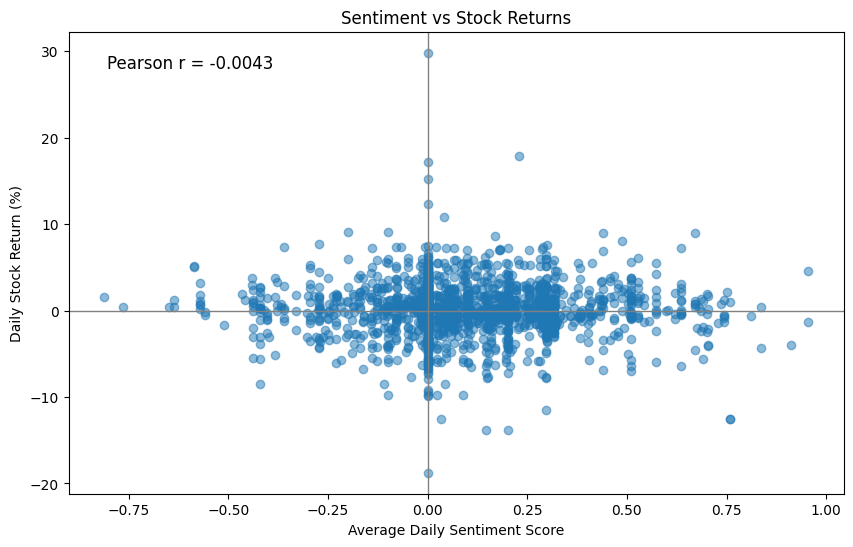

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# scatter plot
plt.scatter(
    merged_df["sentiment_score"],
    merged_df["daily_return"],
    alpha=0.5
)

# labels
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Stock Return (%)")
plt.title("Sentiment vs Stock Returns")

# annotate correlation
corr = merged_df["sentiment_score"].corr(
    merged_df["daily_return"]
)

plt.text(
    0.05, 0.95,
    f"Pearson r = {corr:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.show()

sentiment_category
Negative    0.114370
Neutral     0.097630
Positive    0.208034
Name: daily_return, dtype: float64


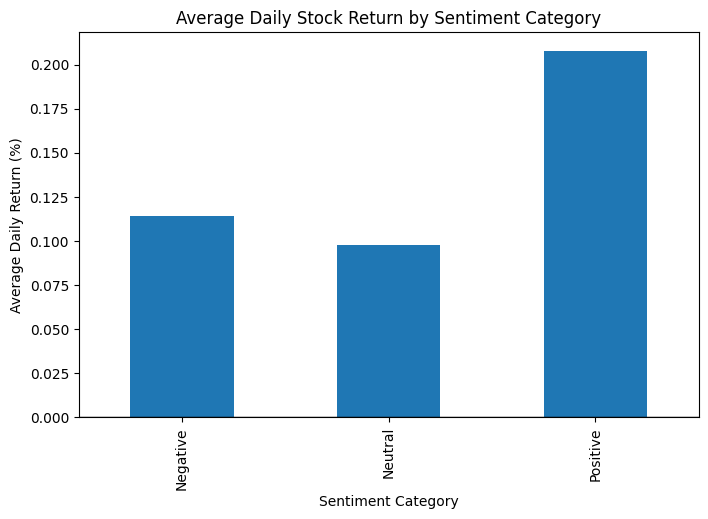

In [9]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

daily_sentiment["sentiment_category"] = daily_sentiment["sentiment_score"].apply(
    classify_sentiment
)
merged_df = pd.merge(
    daily_sentiment,
    stock_df[["trading_date", "daily_return"]],
    on="trading_date",
    how="inner"
)
category_returns = merged_df.groupby("sentiment_category")["daily_return"].mean()
print(category_returns)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_returns.plot(kind="bar")

plt.title("Average Daily Stock Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.axhline(0, color="black", linewidth=1)

plt.show()